# **Data Preprocessing**

## *Download*

Import needed modules.

In [2]:
import requests
import os

from tqdm.notebook import tqdm

Define some parameters.

In [3]:
# time interval for the dataset
YEAR: int = 2025
MONTH: int = 7

DAY_FROM: int = 1   # first day considered
DAY_TO: int = 7     # last day considered


# download
SOURCE: str = "http://aisdata.ais.dk/"
DOWNLOAD_PATH: str = "dataset/raw"

Download considered files.

In [4]:
# download all zips for each required day
for day in tqdm(range(DAY_FROM, DAY_TO + 1), desc="Download progress"):
    # build url
    filename: str = f"aisdk-{YEAR}-{MONTH:02d}-{day:02d}.zip"
    url: str = SOURCE + filename

    # create folder
    os.makedirs(DOWNLOAD_PATH, exist_ok=True)
    filename = DOWNLOAD_PATH + "/" + filename

    # download file
    with requests.get(url, stream=True) as r:
        with open(filename, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024):  # 1 MB chunks
                if chunk:
                    f.write(chunk)

Download progress:   0%|          | 0/7 [00:00<?, ?it/s]

## *Data Wrangling*

In [43]:
import numpy as np
import pandas as pd

Define parameters.

In [44]:
# track filtering and segmentation
MIN_TRACK_LENGTH: int = 256         # minimum number of samples for a segment to be kept
MIN_SOG: int = 1                    # in knots
MAX_SOG: int = 50                   # in knots
MIN_TIMESPAN_TRACK: int = 3600      # one hour
MIN_TIMESPAN_SEGMENT: int = 900     # 15 minutes

# grid limits and cell parameters
TOP_LEFT: tuple[int, int] = (0.0, 60.0)
BOTTOM_RIGHT: tuple[int, int] = (20.0, 50.0)
CELL_DIMENSIONS: tuple[int, int] = (0.01, 0.01)   # dimensions of the single cell in the grid

Define helpers.

In [5]:
def filter_track(df, minimum_timespan):
    df = df.groupby("MMSI").filter(     # filter tracks based on whether some criteria are followed
        lambda x:
        len(x) >= MIN_TRACK_LENGTH and  # remove short segments
        x["SOG"].max() >= MIN_SOG and   # remove ships not in a specific range
        x["SOG"].max() <= MAX_SOG and
        (x["# Timestamp"].max() - x["# Timestamp"].min()).total_seconds() >= minimum_timespan   # remove tracks that don't span enough time
    )

    return df


def clean_data(df):
    north, west, south, east = TOP_LEFT[1], TOP_LEFT[0], BOTTOM_RIGHT[1], BOTTOM_RIGHT[0]   # remove data outside the box
    df = df[(df["Latitude"] <= north) & (df["Latitude"] > south) & \
            (df["Longitude"] >= west) & (df["Longitude"] < east)]

    df = df[df["Type of mobile"].isin(["Class A", "Class B"])]  # keep only class A and class B ship types
    df = df[df["MMSI"].str.len() == 9]                          # adhere to MMSI format
    df = df[df["MMSI"].str[:3].astype(int).between(200, 775)]   # adhere to MID standard
    df["# Timestamp"] = pd.to_datetime(df["# Timestamp"], format="%H:%M:%S", errors="coerce")   # transform timestamp into datetime format

    df = df.drop_duplicates(["# Timestamp", "MMSI"], keep="first")  # drop duplicates in terms of ship ID and timestamp

    df = filter_track(df, MIN_TIMESPAN_TRACK)   # filter irrelevant tracks
    df = df.sort_values(['MMSI', '# Timestamp'])  # sort by ID and timestamp

    return df


def make_segments(df):
    df['Segment'] = df.groupby('MMSI')['# Timestamp'].transform(
        lambda x: (x.diff().dt.total_seconds().fillna(0) >= MIN_TIMESPAN_SEGMENT).cumsum()
    )

    df = filter_track(df.groupby(["MMSI", "Segment"]), MIN_TIMESPAN_SEGMENT)    # divide samples into segments
    df = df.reset_index(drop=True)

    return df


def transform_dataframe(df):
    # change column names
    df = df.rename(columns={
        "# Timestamp": "timestamp",
        "Type of mobile": "type",
        "Latitude": "y",
        "Longitude": "x"
        })

    # transform attributes
    df["SOG"] = 0.514444 * df["SOG"]    # transform speed from knots to meters per second
    cog = np.deg2rad(df['COG']); df['COG_sin'] = np.sin(cog); df['COG_cos'] = np.cos(cog)    # transform COG into sine and cosine for continuity between 360° and 0°
    df = df.drop(['COG'])

    return df

Read dataframe and perform wrangling.

In [1]:
# define attributes and read dataframe
dtypes = {
    "MMSI": "object",
    "SOG": float,
    "COG": float,
    "Longitude": float,
    "Latitude": float,
    "# Timestamp": "object",
    "Type of mobile": "object",
}
df = pd.read_csv("/content/dataset/raw/aisdk-2025-07-01.zip", usecols=list(dtypes.keys()), dtype=dtypes)

df = clean_data(df)
df = make_segments(df)
df = transform_dataframe(df)

NameError: name 'pd' is not defined

Interpolate segments and quantize time.

In [ ]:
import pandas
import pyarrow
import pyarrow.parquet
from sklearn.cluster import KMeans


def fn(file_path, out_path):
    dtypes = {
        "MMSI": "object",
        "SOG": float,
        "COG": float,
        "Longitude": float,
        "Latitude": float,
        "# Timestamp": "object",
        "Type of mobile": "object",
    }
    df = pandas.read_csv(file_path, usecols=list(dtypes.keys()), dtype=dtypes)

    # clean data
    north, west, south, east = TOP_LEFT[1], TOP_LEFT[0], BOTTOM_RIGHT[1], BOTTOM_RIGHT[0]   # remove data outside the box
    df = df[(df["Latitude"] <= north) & (df["Latitude"] > south) & \
            (df["Longitude"] >= west) & (df["Longitude"] < east)]

    df = df[df["Type of mobile"].isin(["Class A", "Class B"])]  # keep only class A and class B ship types
    df = df[df["MMSI"].str.len() == 9]                          # adhere to MMSI format
    df = df[df["MMSI"].str[:3].astype(int).between(200, 775)]   # adhere to MID standard

    # df = df.rename(columns={
    #     "# Timestamp": "timestamp",
    #     "Type of mobile": "type"
    #     })

    df["# Timestamp"] = pandas.to_datetime(df["# Timestamp"], format="%H:%M:%S", errors="coerce")   # reformat timestamp

    df = df.drop_duplicates(["# Timestamp", "MMSI"], keep="first")  # drop duplicates in terms of ship ID and timestamp

    def track_filter(g):
        len_filt = len(g) > 256  # Min required length of track/segment
        sog_filt = 1 <= g["SOG"].max() <= 50  # Remove stationary tracks/segments
        time_filt = (g["Timestamp"].max() - g["Timestamp"].min()).total_seconds() >= 60 * 60  # Min required timespan
        return len_filt and sog_filt and time_filt

    # Track filtering
    df = df.groupby("MMSI").filter(track_filter)
    df = df.sort_values(['MMSI', 'Timestamp'])

    # Divide track into segments based on timegap
    df['Segment'] = df.groupby('MMSI')['Timestamp'].transform(
        lambda x: (x.diff().dt.total_seconds().fillna(0) >= 15 * 60).cumsum())  # Max allowed timegap

    # Segment filtering
    df = df.groupby(["MMSI", "Segment"]).filter(track_filter)
    df = df.reset_index(drop=True)

    #
    knots_to_ms = 0.514444
    df["SOG"] = knots_to_ms * df["SOG"]

    # df["Date"] = df["Timestamp"].dt.strftime("%Y-%m-%d")
    # Save as parquet file with partitions
    table = pyarrow.Table.from_pandas(df, preserve_index=False)
    pyarrow.parquet.write_to_dataset(
        table,
        root_path=out_path,
        partition_cols=["MMSI",  # "Date",
                        "Segment",  # "Geocell"
                        ]
    )


In [ ]:
df = clean_data(df)
df = make_segments(df)
df = transform_attributes(df)

In [ ]:
fn("dataset/aisdk-2025-10-31.zip", "temp")

In [ ]:
import pandas as pd



df = pd.read_parquet("/content/temp/MMSI=209114000/Segment=1/311bcd60526a4a49955be660ab350400-0.parquet")

In [ ]:
print(df.head(150))

              Timestamp Type of mobile   Latitude  Longitude       SOG    COG
0   2025-10-31 00:57:52        Class A  57.655502  11.739293  3.806886  255.8
1   2025-10-31 01:02:32        Class A  57.652613  11.722038  3.858330  252.7
2   2025-10-31 01:03:12        Class A  57.652207  11.719588  3.909774  252.3
3   2025-10-31 01:04:32        Class A  57.651363  11.714458  3.961219  252.6
4   2025-10-31 01:10:02        Class A  57.644233  11.698418  3.858330  212.3
..                  ...            ...        ...        ...       ...    ...
145 2025-10-31 02:26:43        Class A  57.503708  11.644700  3.395330  161.0
146 2025-10-31 02:27:03        Class A  57.503140  11.645103  3.395330  160.6
147 2025-10-31 02:27:13        Class A  57.502857  11.645313  3.395330  158.4
148 2025-10-31 02:27:23        Class A  57.502603  11.645503  3.395330  158.4
149 2025-10-31 02:27:32        Class A  57.502347  11.645683  3.395330  158.2

[150 rows x 6 columns]


In [ ]:
print(df.columns)

Index(['Timestamp', 'Type of mobile', 'Latitude', 'Longitude', 'SOG', 'COG'], dtype='object')


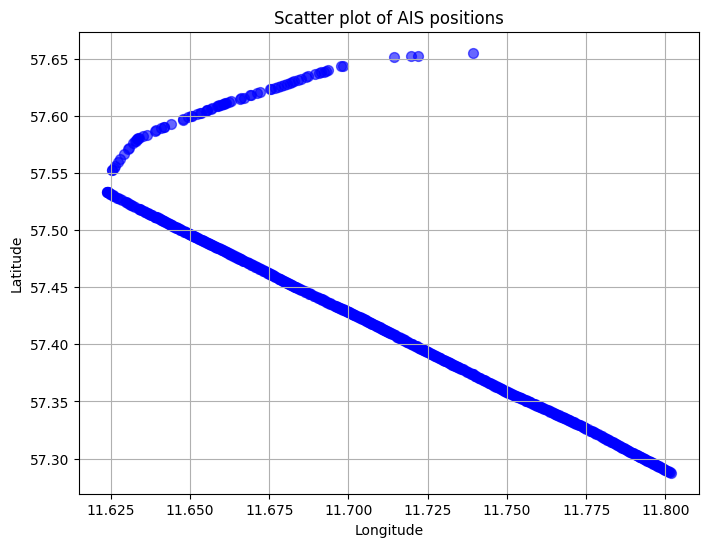

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], c='blue', alpha=0.6, s=50)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scatter plot of AIS positions")
plt.grid(True)
plt.show()

## *Interpolation*

## *Discretization*

Define some parameters.

In [ ]:
# define discretization parameters
TOP_LEFT: tuple[int, int] = (0.0, 60.0)
BOTTOM_RIGHT: tuple[int, int] = (20.0, 50.0)

CELL_DIMENSIONS: tuple[int, int] = (0.01, 0.01)   # dimensions of the single cell in the grid

Define helper functions.

In [ ]:
def retrieve_cell(lon: float, lat: float) -> tuple[int, int]:
    if not (TOP_LEFT[0] <= lon and lon < BOTTOM_RIGHT[0] and BOTTOM_RIGHT[1] < lat and lat <= TOP_LEFT[1]):
        return None

    x: int = (lon - TOP_LEFT[0]) / CELL_DIMENSIONS[0]
    y: int = (lat - BOTTOM_RIGHT[1]) / CELL_DIMENSIONS[1]

    return x, y

In [ ]:
print(retrieve_cell(16, 61))

None


interpolare, quantizzare tempo, discretizzare spazio (trasformare in celle), trasformare angolo in seno e coseno

In [ ]:
cog_rad = np.deg2rad(cog_degrees)
cog_sin = np.sin(cog_rad)
cog_cos = np.cos(cog_rad)

## **Model**

In [ ]:
import torch
import torch.nn as nn

class MaritimeLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_layers=1, num_classes=9, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        """
        x: (batch_size, seq_len, input_dim)
        returns logits: (batch_size, num_classes)
        """
        output, (h_n, c_n) = self.lstm(x)
        # h_n: (num_layers, batch_size, hidden_dim)
        last_hidden = h_n[-1]                 # (batch_size, hidden_dim)
        logits = self.fc(last_hidden)         # (batch_size, num_classes)
        return logits

    def predict_proba(self, x):
        """Return probabilities over the 9 cells."""
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)
            probs = torch.softmax(logits, dim=-1)
        return probs
